In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

random_state = 42

# Gradient Boosting

In [4]:
cancer_deaths = pd.read_csv(r'..\Processed Data\cdc_cancer_deaths_encoded.csv')
cancer_deaths.head()

,AGE,CAUSE_RECODE_113,DATA_YEAR,EDUCATION_CODED,HISPANIC_CODED,MANNER_OF_DEATH_CODED,MONTH_OF_DEATH,PLACE_OF_DEATH_CODED,RESIDENT_STATUS_CODED,WEEKDAY_OF_DEATH,...,PLACE_OF_DEATH_Hospital (Dead on Arrival),PLACE_OF_DEATH_Hospital (Inpatient),PLACE_OF_DEATH_Hospital (Outpatient/ER),PLACE_OF_DEATH_Nursing home,PLACE_OF_DEATH_Other,PLACE_OF_DEATH_Unknown,AUTOPSY_N,AUTOPSY_U,AUTOPSY_Y,AUTOPSY_n
0,93.0,33,2018,61,6,7.0,1,6,1,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,61.0,23,2018,51,6,7.0,1,4,1,4,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,63.0,25,2018,41,6,7.0,1,4,1,5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,67.0,27,2018,31,6,7.0,1,4,1,6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,76.0,27,2018,31,6,7.0,1,4,1,2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [24]:
# fixing data leakage (SEX_CODED_F and cancer types that accurately leak the sex of the patient)
X = cancer_deaths.drop(columns=['SEX_Female', 'SEX_Male', 'SEX_CODED_F', 'CAUSE_OF_DEATH_Malignant neoplasm of breast (C50)', 'CAUSE_OF_DEATH_Malignant neoplasm of prostate (C61)', 'CAUSE_OF_DEATH_Malignant neoplasm of ovary (C56)', 'CAUSE_OF_DEATH_Malignant neoplasms of corpus uteri and uterus, part unspecified (C54-C55)', 'CAUSE_OF_DEATH_Malignant neoplasm of cervix uteri (C53)', 'CAUSE_RECODE_113'])
y = cancer_deaths['SEX_Female']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

In [33]:
# BASELINE HGBC (Uses bins to speed up training)
hgbc = HistGradientBoostingClassifier(loss='log_loss', random_state=random_state)
hgbc.fit(X_train, y_train)

y_pred = hgbc.predict(X_test)
hgbc.score(X_test, y_test)

0.6871440427243758

In [36]:
y_prob_base = hgbc.predict_proba(X_test)[:, 1]
y_pred_base = hgbc.predict(X_test)

print("=== BASELINE TEST SET PERFORMANCE ===")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}\n")
print(classification_report(y_test, y_pred_base))

=== BASELINE TEST SET PERFORMANCE ===
Final Test ROC-AUC: 0.7453

              precision    recall  f1-score   support

         0.0       0.68      0.77      0.72    166803
         1.0       0.70      0.60      0.64    148895

    accuracy                           0.69    315698
   macro avg       0.69      0.68      0.68    315698
weighted avg       0.69      0.69      0.68    315698



Text(0.5, 1.0, 'Sex of Cancer Mortality (0 = Male, 1 = Female)\n(Baseline Histogram Gradient Boosting Classifier)')

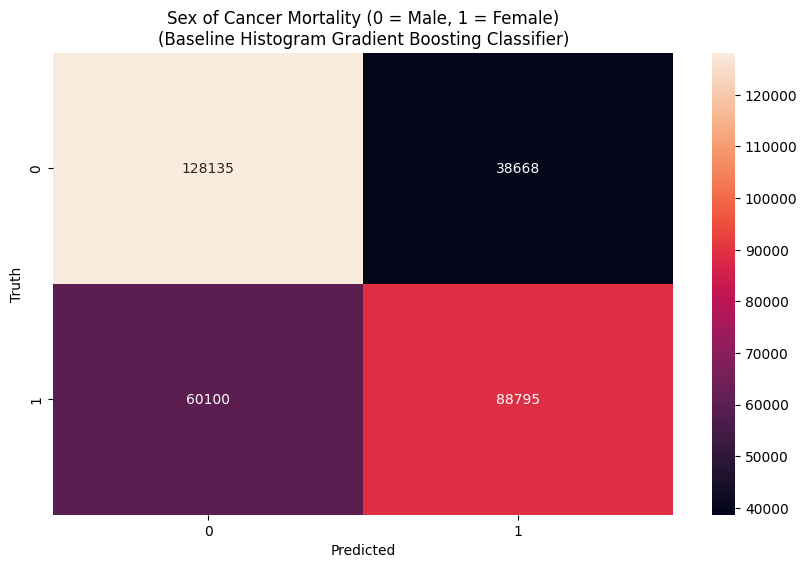

In [35]:
cm_base = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_base, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Sex of Cancer Mortality (0 = Male, 1 = Female)\n(Baseline Histogram Gradient Boosting Classifier)')

In [18]:
param_grid = {
    'loss': ['log_loss'],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_iter': [100, 250],
    'max_depth': [3, 4, 5],
}

grid_search = GridSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=random_state),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_hgbc = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC Score:", grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=100; total time=  20.9s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=100; total time=  21.0s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=100; total time=  20.1s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=100; total time=  18.5s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=100; total time=  17.2s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=250; total time=  33.6s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=250; total time=  33.5s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=250; total time=  33.6s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=250; total time=  33.5s
[CV] END learning_rate=0.01, loss=log_loss, max_depth=3, max_iter=250; total time=  35.5s
[CV] END learning_rate=0.01, loss=log_l

In [20]:
best_params = grid_search.best_params_

In [31]:
y_prob = best_hgbc.predict_proba(X_test)[:, 1]
y_pred = best_hgbc.predict(X_test)

print("=== FINAL TEST SET PERFORMANCE ===")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}\n")
print(classification_report(y_test, y_pred))

=== FINAL TEST SET PERFORMANCE ===
Final Test ROC-AUC: 0.7433

              precision    recall  f1-score   support

         0.0       0.68      0.76      0.72    166803
         1.0       0.69      0.60      0.64    148895

    accuracy                           0.69    315698
   macro avg       0.69      0.68      0.68    315698
weighted avg       0.69      0.69      0.68    315698



Text(0.5, 1.0, 'Sex of Cancer Mortality (0 = Male, 1 = Female)\n(Hypertuned Histogram Gradient Boosting Classifier)')

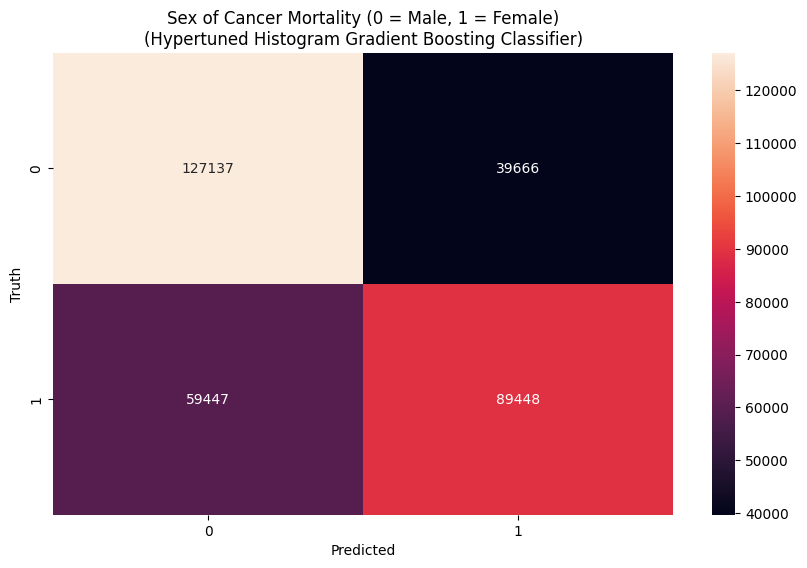

In [32]:
cm_tuned = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Sex of Cancer Mortality (0 = Male, 1 = Female)\n(Hypertuned Histogram Gradient Boosting Classifier)')

Hypertuned Model with 5-fold CV Outcome:
  - Reduction of 999 true predictions of male cancer mortalities (Worse)
  - Reduction of 653 false predictions of male cancer mortalities (**Better**)
  - Increase of 998 false predictions of female cancer mortalities (Worse)
  - Increase of 653 true predictions of female cancer mortalities (**Better**)
  - Slight decrease in ROC-AUC score -0.002 (Worse)

There was a slight decrease in performance overall based on the ROC-AUC scores, but they are essentially the same (only a 0.002 difference). The ceiling has likely been met, but I can run another round of 5-fold CV and expand the hyperparameters to see if I can ge more predictive power out of the data. If not, I would need to do some feature engineering and potentially feature selection.

In [37]:
# HYPERPARAMETER SEARCH 2

param_grid2 = {
    'loss': ['log_loss'],
    'learning_rate': [0.1, 0.15, 0.2],
    'max_iter': [150, 250],
    'max_depth': [5, 6, 7],
}

grid_search2 = GridSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=random_state),
    param_grid=param_grid2,
    scoring='roc_auc',
    cv=5,
    n_jobs=1,
    verbose=2
)

grid_search2.fit(X_train, y_train)

best_hgbc2 = grid_search2.best_estimator_

print("Best Parameters:", grid_search2.best_params_)
print("Best ROC-AUC Score:", grid_search2.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=150; total time=  25.1s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=150; total time=  24.7s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=150; total time=  24.5s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=150; total time=  24.3s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=150; total time=  24.2s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=250; total time=  36.9s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=250; total time=  37.1s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=250; total time=  36.6s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=250; total time=  37.0s
[CV] END learning_rate=0.1, loss=log_loss, max_depth=5, max_iter=250; total time=  37.8s
[CV] END learning_rate=0.1, loss=log_loss, max_de

In [38]:
best_params2 = grid_search2.best_params_

In [39]:
y_prob2 = best_hgbc2.predict_proba(X_test)[:, 1]
y_pred2 = best_hgbc2.predict(X_test)

print("=== FINAL TEST SET PERFORMANCE ===")
print(f"Final Test ROC-AUC: {roc_auc_score(y_test, y_prob2):.4f}\n")
print(classification_report(y_test, y_pred2))

=== FINAL TEST SET PERFORMANCE ===
Final Test ROC-AUC: 0.7458

              precision    recall  f1-score   support

         0.0       0.68      0.77      0.72    166803
         1.0       0.70      0.60      0.64    148895

    accuracy                           0.69    315698
   macro avg       0.69      0.68      0.68    315698
weighted avg       0.69      0.69      0.68    315698



Text(0.5, 1.0, 'Sex of Cancer Mortality (0 = Male, 1 = Female)\n(Hypertuned Histogram Gradient Boosting Classifier - V2)')

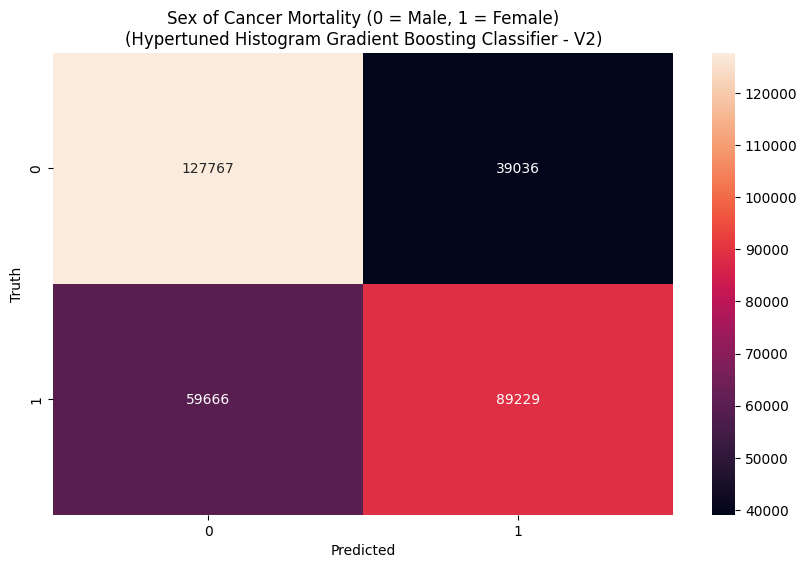

In [40]:
cm_tuned2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(10, 6))
sns.heatmap(cm_tuned2, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Sex of Cancer Mortality (0 = Male, 1 = Female)\n(Hypertuned Histogram Gradient Boosting Classifier - V2)')

Hypertuned Model V2 with 5-fold CV Outcome Comparison with Hypertuned V1:
  - Increase of 630 true predictions of male cancer mortalities (**Better**)
  - Increase of 219 false predictions of male cancer mortalities (Worse)
  - Reduction of 630 false predictions of female cancer mortalities (**Better**)
  - Reduction of 219 true predictions of female cancer mortalities (Worse)
  - Slight increase in ROC-AUC score +0.0025 (**Better**)

The second hypertuned model is more complex due to the larger max_depth. With the added complexity, there is not a very significant difference in the models' accuracies, ROC-AUC, precision, recall, and f1-scores. While V2 improved the accuracy for true male cancer mortalities, V1 was better with true female cancer mortalities. The trade-off between the models are the false predictions of male and female cancer mortalities. For V1, it had lower false male predictions. For V2, it had lower false female predictions. Overall, my preference is with V1 due to its simpler model. V2 is still great, but it has a higher risk of overfitting due to the larger max_depth. Considering that my focus is on health disparities, I need to avoid potential for overfitting because it might inadvertently hide systemic disparities by overfitting rather than generalizing the true picture of the multidimensional data.